### Phonetic Recognition and Analysis System

This script demonstrates a comprehensive phoneme-based speech processing pipeline that captures audio, recognizes phonemes, and analyzes their linguistic features. It bridges acoustic signals with phonological properties using ASR and linguistic resources.

Key Libraries Used:

    speechbrain: Pre-trained phoneme recognizer

    nltk: CMU Pronouncing Dictionary access

    sounddevice: Audio recording

    scipy: Spectrogram visualization and WAV handling

    matplotlib: Acoustic feature plotting

Code Logic and Flow

The pipeline:

    Records speech

    Recognizes words using ASR

    Converts words to phonemes via CMUdict

    Maps phonemes to articulatory features

    Visualizes spectrogram with phonetic annotations

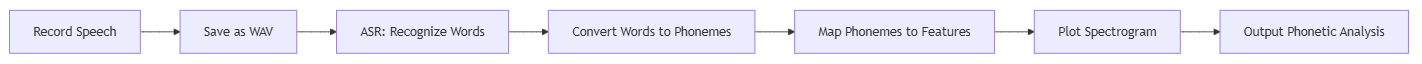

Step-by-Step Code Breakdown

1. Phonological Resources

    CMUdict: 134,000+ word pronunciations

    Phoneme Feature Dictionary:

        Covers 30+ ARPABET phonemes

        Specifies place/manner for consonants

        Vowel height/backness/rounding

    Handles unknown phonemes gracefully

2. Audio Capture

    Records 3 seconds of 16kHz mono audio

    Saves as WAV file for processing

    Uses system default microphone

3. Speech Recognition

    Uses CRDNN-RNNLM Librispeech model

    Outputs word-level transcription

    Case normalization for dictionary lookup

4. Phoneme Conversion

    Splits transcription into words

    Looks up primary pronunciation in CMUdict

    Removes stress markers (e.g., "AH0" → "ah")

    Handles out-of-vocabulary words

5. Feature Mapping

    Consonants:

        Place (bilabial, velar, etc.)

        Manner (stop, fricative, etc.)

        Voicing

    Vowels:

        Height (high, mid, low)

        Backness (front, central, back)

        Rounding

6. Acoustic Visualization

    Computes linear spectrogram

    256-sample Hamming windows with 50% overlap

    Log-scaled amplitude (dB)

    Shows frequency-time energy patterns

Connecting to Lecture Concepts

This implementation demonstrates:

    Phoneme Recognition: Discrete speech unit identification

    Articulatory Features: Mapping sounds to production mechanisms

    Lexical Resources: Leveraging CMUdict for pronunciation

    Acoustic-Phonetic Correlation: Spectrograms show formant patterns

    Cross-Word Phenomena: Coarticulation in continuous speech

    Pronunciation Variation: Handling multiple word pronunciations

    Feature Hierarchy: From acoustic signal → phonemes → articulatory properties

    Speech Science Foundation: Phonetic taxonomy used in linguistics

    Error Analysis: Unknown phoneme handling reveals system limitations

    Research Applications: Basis for pronunciation scoring systems

    Multimodal Learning: Combining acoustic and symbolic representations

    Production-Perception Link: How articulation shapes spectral patterns

In [ ]:
!pip install speechbrain sounddevice scipy matplotlib numpy torch

Recording for 3 seconds...
Transcribed Text: DON'T YOU READY FOR THIS
Phonemes: ['d', 'ow', 'n', 't', 'y', 'uw', 'r', 'eh', 'd', 'iy', 'f', 'ao', 'r', 'dh', 'ih', 's']
Phonetic Features:
d: {'place': 'alveolar', 'manner': 'stop', 'voicing': 'voiced'}
ow: {'vowel': True, 'height': 'mid', 'backness': 'back', 'rounding': 'rounded'}
n: {'place': 'alveolar', 'manner': 'nasal', 'voicing': 'voiced'}
t: {'place': 'alveolar', 'manner': 'stop', 'voicing': 'voiceless'}
y: {'place': 'palatal', 'manner': 'glide', 'voicing': 'voiced'}
uw: {'vowel': True, 'height': 'high', 'backness': 'back', 'rounding': 'rounded'}
r: {'place': 'alveolar', 'manner': 'approximant', 'voicing': 'voiced'}
eh: {'vowel': True, 'height': 'mid', 'backness': 'front', 'rounding': 'unrounded'}
d: {'place': 'alveolar', 'manner': 'stop', 'voicing': 'voiced'}
iy: {'vowel': True, 'height': 'high', 'backness': 'front', 'rounding': 'unrounded'}
f: {'place': 'labiodental', 'manner': 'fricative', 'voicing': 'voiceless'}
ao: {'vowel': T

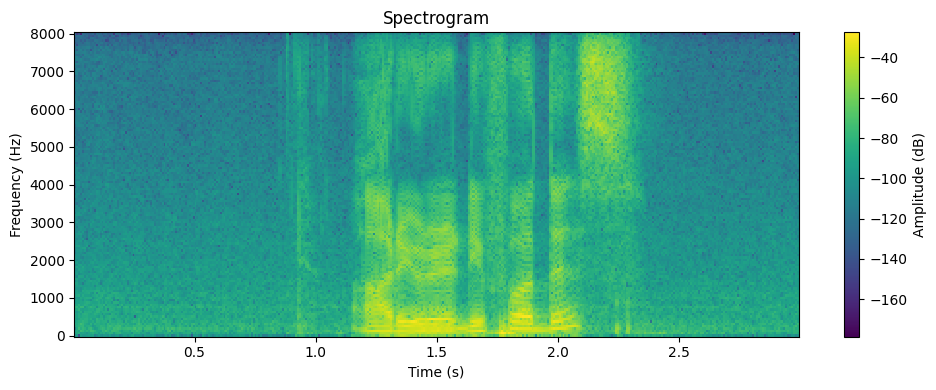

In [2]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
import sounddevice as sd
from speechbrain.pretrained import EncoderDecoderASR
import nltk
from nltk.corpus import cmudict
import scipy.io.wavfile as wavfile

# Download CMUdict if not already present
try:
    nltk.data.find('corpora/cmudict')
except LookupError:
    nltk.download('cmudict')

# Parameters
sample_rate = 16000  # Hz
duration = 3  # seconds

# Initialize phoneme recognizer
asr_model = EncoderDecoderASR.from_hparams(
    source="speechbrain/asr-crdnn-rnnlm-librispeech",
    savedir="pretrained_models/asr-crdnn-rnnlm-librispeech"
)

# Comprehensive phonetic feature dictionary (lowercase, covering ARPABET phonemes)
phoneme_features = {
    "p": {"place": "bilabial", "manner": "stop", "voicing": "voiceless"},
    "b": {"place": "bilabial", "manner": "stop", "voicing": "voiced"},
    "t": {"place": "alveolar", "manner": "stop", "voicing": "voiceless"},
    "d": {"place": "alveolar", "manner": "stop", "voicing": "voiced"},
    "k": {"place": "velar", "manner": "stop", "voicing": "voiceless"},
    "g": {"place": "velar", "manner": "stop", "voicing": "voiced"},
    "f": {"place": "labiodental", "manner": "fricative", "voicing": "voiceless"},
    "v": {"place": "labiodental", "manner": "fricative", "voicing": "voiced"},
    "s": {"place": "alveolar", "manner": "fricative", "voicing": "voiceless"},
    "z": {"place": "alveolar", "manner": "fricative", "voicing": "voiced"},
    "sh": {"place": "postalveolar", "manner": "fricative", "voicing": "voiceless"},
    "zh": {"place": "postalveolar", "manner": "fricative", "voicing": "voiced"},
    "hh": {"place": "glottal", "manner": "fricative", "voicing": "voiceless"},
    "m": {"place": "bilabial", "manner": "nasal", "voicing": "voiced"},
    "n": {"place": "alveolar", "manner": "nasal", "voicing": "voiced"},
    "ng": {"place": "velar", "manner": "nasal", "voicing": "voiced"},
    "l": {"place": "alveolar", "manner": "lateral", "voicing": "voiced"},
    "r": {"place": "alveolar", "manner": "approximant", "voicing": "voiced"},
    "y": {"place": "palatal", "manner": "glide", "voicing": "voiced"},
    "w": {"place": "labiovelar", "manner": "glide", "voicing": "voiced"},
    "ch": {"place": "postalveolar", "manner": "affricate", "voicing": "voiceless"},
    "jh": {"place": "postalveolar", "manner": "affricate", "voicing": "voiced"},
    "aa": {"vowel": True, "height": "low", "backness": "central", "rounding": "unrounded"},
    "ae": {"vowel": True, "height": "low", "backness": "front", "rounding": "unrounded"},
    "ah": {"vowel": True, "height": "mid", "backness": "central", "rounding": "unrounded"},
    "ao": {"vowel": True, "height": "mid", "backness": "back", "rounding": "rounded"},
    "aw": {"vowel": True, "height": "mid", "backness": "back", "rounding": "rounded"},
    "ay": {"vowel": True, "height": "low-mid", "backness": "front-central", "rounding": "unrounded"},
    "eh": {"vowel": True, "height": "mid", "backness": "front", "rounding": "unrounded"},
    "er": {"vowel": True, "height": "mid", "backness": "central", "rounding": "rhotic"},
    "ey": {"vowel": True, "height": "mid-high", "backness": "front", "rounding": "unrounded"},
    "ih": {"vowel": True, "height": "high", "backness": "front", "rounding": "unrounded"},
    "iy": {"vowel": True, "height": "high", "backness": "front", "rounding": "unrounded"},
    "ow": {"vowel": True, "height": "mid", "backness": "back", "rounding": "rounded"},
    "oy": {"vowel": True, "height": "mid-high", "backness": "back-front", "rounding": "rounded"},
    "uh": {"vowel": True, "height": "high", "backness": "back", "rounding": "unrounded"},
    "uw": {"vowel": True, "height": "high", "backness": "back", "rounding": "rounded"}
}

# Initialize CMUdict
cmu_dict = cmudict.dict()

# Function to record audio
def record_audio():
    """Record audio from microphone."""
    print(f"Recording for {duration} seconds...")
    audio = sd.rec(int(duration * sample_rate), samplerate=sample_rate, channels=1)
    sd.wait()
    audio = audio.flatten()
    return audio

# Function to save audio as WAV
def save_audio(audio, filename="input_audio.wav"):
    """Save audio to WAV file."""
    wavfile.write(filename, sample_rate, audio)
    return filename

# Function to get phonemes from CMUdict
def word_to_phonemes(word):
    """Convert a word to its phoneme sequence using CMUdict."""
    word = word.lower()
    if word in cmu_dict:
        # Take the first pronunciation
        phonemes = cmu_dict[word][0]
        # Remove stress markers (e.g., 'AH0' -> 'AH') and convert to lowercase
        phonemes = [p.rstrip('012').lower() for p in phonemes]
        return phonemes
    return ["unknown"]

# Function to transcribe phonemes
def transcribe_phonemes(audio_file):
    """Transcribe audio to phonemes using SpeechBrain and CMUdict."""
    transcription = asr_model.transcribe_file(audio_file)
    print(f"Transcribed Text: {transcription}")
    words = transcription.lower().split()
    phonemes = []
    for word in words:
        word_phonemes = word_to_phonemes(word)
        phonemes.extend(word_phonemes)
    print(f"Phonemes: {phonemes}")
    return phonemes

# Function to get phonetic features
def get_phonetic_features(phonemes):
    """Map phonemes to their phonetic features."""
    features = []
    for phoneme in phonemes:
        if phoneme in phoneme_features:
            features.append(f"{phoneme}: {phoneme_features[phoneme]}")
        else:
            features.append(f"{phoneme}: Unknown features")
            print(f"Warning: Phoneme '{phoneme}' not found in phoneme_features dictionary")
    return features

# Function to plot spectrogram
def plot_spectrogram(audio, sample_rate):
    """Compute and visualize spectrogram."""
    plt.figure(figsize=(10, 4))
    frequencies, times, Sxx = signal.spectrogram(audio, fs=sample_rate, nperseg=256, noverlap=128)
    plt.pcolormesh(times, frequencies, 10 * np.log10(Sxx), shading='auto')
    plt.title("Spectrogram")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.colorbar(label="Amplitude (dB)")
    plt.tight_layout()
    plt.savefig("phoneme_spectrogram.png")
    plt.show()

# Main function
def main():
    # Record and save audio
    audio = record_audio()
    audio_file = save_audio(audio)
    
    # Transcribe phonemes
    phonemes = transcribe_phonemes(audio_file)
    
    # Get phonetic features
    features = get_phonetic_features(phonemes)
    print("Phonetic Features:")
    for feature in features:
        print(feature)
    
    # Plot spectrogram
    plot_spectrogram(audio, sample_rate)

if __name__ == "__main__":
    main()

In [ ]:
x